<a href="https://colab.research.google.com/github/NamNam9252/Deep-Learning/blob/main/Activation-Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

SELECT ACTIVATION FUNCTION
1. ReLU
2. Sigmoid
3. Tanh
4. Leaky ReLU
5. Softmax
Enter choice (1-5): 1

SELECT OPTIMIZER
1. Adam
2. SGD
3. RMSprop
Enter choice (1-3): 1
Epoch 01 | Loss = 1.4706 | Accuracy = 0.0567
Epoch 02 | Loss = 0.6292 | Accuracy = 0.6337
Epoch 03 | Loss = 0.2566 | Accuracy = 0.9907
Epoch 04 | Loss = 0.1325 | Accuracy = 0.9940
Epoch 05 | Loss = 0.0832 | Accuracy = 0.9940
Epoch 06 | Loss = 0.0591 | Accuracy = 0.9947
Epoch 07 | Loss = 0.0456 | Accuracy = 0.9950
Epoch 08 | Loss = 0.0372 | Accuracy = 0.9950
Epoch 09 | Loss = 0.0316 | Accuracy = 0.9953
Epoch 10 | Loss = 0.0277 | Accuracy = 0.9957
Epoch 11 | Loss = 0.0248 | Accuracy = 0.9957
Epoch 12 | Loss = 0.0226 | Accuracy = 0.9957
Epoch 13 | Loss = 0.0210 | Accuracy = 0.9953
Epoch 14 | Loss = 0.0197 | Accuracy = 0.9953
Epoch 15 | Loss = 0.0186 | Accuracy = 0.9953
Epoch 16 | Loss = 0.0178 | Accuracy = 0.9953
Epoch 17 | Loss = 0.0171 | Accuracy = 0.9953
Epoch 18 | Loss 

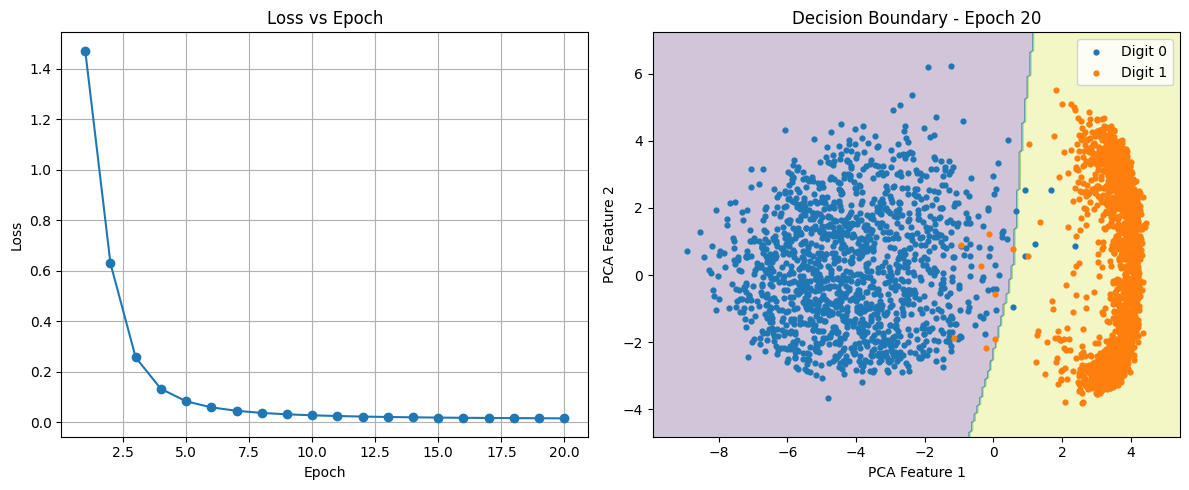

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


# ============================================================
# 2. LOAD BUILT-IN MNIST DATASET
# ============================================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Keep only digits 0 and 1
train_mask = (y_train == 0) | (y_train == 1)
test_mask = (y_test == 0) | (y_test == 1)

x_train = x_train[train_mask]
y_train = y_train[train_mask]

x_test = x_test[test_mask]
y_test = y_test[test_mask]


# ============================================================
# 3. PREPROCESSING
# ============================================================

# Flatten 28x28 images -> 784 features
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# Normalize pixels
x_train = x_train / 255.0
x_test = x_test / 255.0


# ============================================================
# 4. PCA: 784 FEATURES -> 2 FEATURES
#    Needed for 2D decision boundary
# ============================================================

pca = PCA(n_components=2)

x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

# Use smaller dataset for faster dynamic plotting
x_train = x_train[:3000]
y_train = y_train[:3000]

x_test = x_test[:1000]
y_test = y_test[:1000]


# ============================================================
# 5. USER SELECTS ACTIVATION FUNCTION
# ============================================================

print("\n==============================")
print("SELECT ACTIVATION FUNCTION")
print("==============================")
print("1. ReLU")
print("2. Sigmoid")
print("3. Tanh")
print("4. Leaky ReLU")
print("5. Softmax")

activation_choice = int(input("Enter choice (1-5): "))


def get_activation(choice):

    if choice == 1:
        return tf.keras.layers.ReLU()

    elif choice == 2:
        return tf.keras.layers.Activation("sigmoid")

    elif choice == 3:
        return tf.keras.layers.Activation("tanh")

    elif choice == 4:
        return tf.keras.layers.LeakyReLU(negative_slope=0.01)

    elif choice == 5:
        return tf.keras.layers.Activation("softmax")

    else:
        print("Invalid choice. Using ReLU.")
        return tf.keras.layers.ReLU()


activation = get_activation(activation_choice)


# ============================================================
# 6. USER SELECTS OPTIMIZER
# ============================================================

print("\n==============================")
print("SELECT OPTIMIZER")
print("==============================")
print("1. Adam")
print("2. SGD")
print("3. RMSprop")

optimizer_choice = int(input("Enter choice (1-3): "))


if optimizer_choice == 1:

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001
    )

elif optimizer_choice == 2:

    optimizer = tf.keras.optimizers.SGD(
        learning_rate=0.01
    )

elif optimizer_choice == 3:

    optimizer = tf.keras.optimizers.RMSprop(
        learning_rate=0.001
    )

else:

    print("Invalid choice. Using Adam.")

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001
    )


# ============================================================
# 7. CREATE MODEL
#    ONE HIDDEN LAYER
# ============================================================

model = tf.keras.Sequential([

    # Input layer
    tf.keras.layers.Input(shape=(2,)),

    # ONE hidden layer
    tf.keras.layers.Dense(16),

    # User-selected activation
    activation,

    # Binary classification output
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])


# ============================================================
# 8. COMPILE MODEL
# ============================================================

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 9. DYNAMIC PLOTTING CALLBACK
# ============================================================

class DynamicPlot(tf.keras.callbacks.Callback):

    def on_train_begin(self, logs=None):

        plt.ion()

        self.epochs = []
        self.losses = []

        self.fig, (self.ax1, self.ax2) = plt.subplots(
            1, 2,
            figsize=(12, 5)
        )


    def on_epoch_end(self, epoch, logs=None):

        loss = logs["loss"]
        accuracy = logs["accuracy"]

        self.epochs.append(epoch + 1)
        self.losses.append(loss)


        # ====================================================
        # LEFT: LOSS GRAPH
        # ====================================================

        self.ax1.clear()

        self.ax1.plot(
            self.epochs,
            self.losses,
            marker="o"
        )

        self.ax1.set_title("Loss vs Epoch")
        self.ax1.set_xlabel("Epoch")
        self.ax1.set_ylabel("Loss")
        self.ax1.grid(True)


        # ====================================================
        # RIGHT: DECISION BOUNDARY
        # ====================================================

        self.ax2.clear()

        x_min = x_train[:, 0].min() - 1
        x_max = x_train[:, 0].max() + 1

        y_min = x_train[:, 1].min() - 1
        y_max = x_train[:, 1].max() + 1

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 200),
            np.linspace(y_min, y_max, 200)
        )

        grid = np.c_[
            xx.ravel(),
            yy.ravel()
        ]

        # Predict grid points
        predictions = self.model.predict(
            grid,
            verbose=0
        )

        predictions = (
            predictions > 0.5
        ).astype(int)

        predictions = predictions.reshape(
            xx.shape
        )


        # Draw decision regions
        self.ax2.contourf(
            xx,
            yy,
            predictions,
            alpha=0.25
        )


        # Plot class 0
        self.ax2.scatter(
            x_train[y_train == 0, 0],
            x_train[y_train == 0, 1],
            label="Digit 0",
            s=12
        )


        # Plot class 1
        self.ax2.scatter(
            x_train[y_train == 1, 0],
            x_train[y_train == 1, 1],
            label="Digit 1",
            s=12
        )


        self.ax2.set_title(
            f"Decision Boundary - Epoch {epoch + 1}"
        )

        self.ax2.set_xlabel("PCA Feature 1")
        self.ax2.set_ylabel("PCA Feature 2")

        self.ax2.legend()


        # Update figure
        self.fig.tight_layout()
        self.fig.canvas.draw()
        self.fig.canvas.flush_events()


        print(
            f"Epoch {epoch + 1:02d} | "
            f"Loss = {loss:.4f} | "
            f"Accuracy = {accuracy:.4f}"
        )


# ============================================================
# 10. TRAIN MODEL
# ============================================================

callback = DynamicPlot()

history = model.fit(

    x_train,
    y_train,

    epochs=20,

    batch_size=32,

    validation_data=(
        x_test,
        y_test
    ),

    callbacks=[callback],

    verbose=0
)


# ============================================================
# 11. FINAL EVALUATION
# ============================================================

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

test_error = 1 - test_accuracy


print("\n==============================")
print("FINAL RESULTS")
print("==============================")

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Error    : {test_error:.4f}")
print(f"Test Error %  : {test_error * 100:.2f}%")


plt.ioff()
plt.show()